# 02 - Exploratory Data Analysis
This notebook provides visualisations of the dataset after cleaning


### Imports & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Data/cleaned.csv')

sns.set_theme(style='whitegrid')
COLORS = ['#3C3489', '#0F6E56', '#185FA5', '#D85A30', '#BA7517']

print('Shape:', df.shape)
df.head()

Shape: (680, 31)


,Student ID,Age,Grade,Enjoyment_Score,Student_Feeling,Low_Birth_Weight,Born_Prematurely,Birth_Complications,Family_Math_Difficulty,Parent_Perception_Math,...,Time_Number Line,Score_Arithmetic,Time_Arithmetic,Score_Fractions,Time_Fractions,Score_Money,Time_Money,Score_Time,Time_Time,Performance Gap
0,_ anaya-3,8.9,3,1,1,2,2,2,2,2,...,3.0,0.5,2.0,0.666667,2.7,0.333333,2.3,1.0,3.0,0
1,_abdullah hassan-2,8.4,2,1,1,2,2,2,2,2,...,3.0,1.0,2.5,0.666667,2.0,1.000000,2.7,1.0,2.5,0
2,1-3,8.9,3,1,1,2,2,2,2,2,...,3.5,1.0,3.0,0.333333,3.0,0.666667,3.7,1.0,3.0,0
3,1016,8.0,2,2,2,0,0,0,0,0,...,4.5,1.0,3.0,0.333333,3.7,0.666667,3.0,1.0,3.0,0
4,1017,8.0,2,1,1,2,2,2,2,2,...,3.5,0.5,3.5,0.666667,4.7,0.666667,3.0,1.0,4.0,-1


## 1. Student Demographics

### 1.1 Average Age by Grade

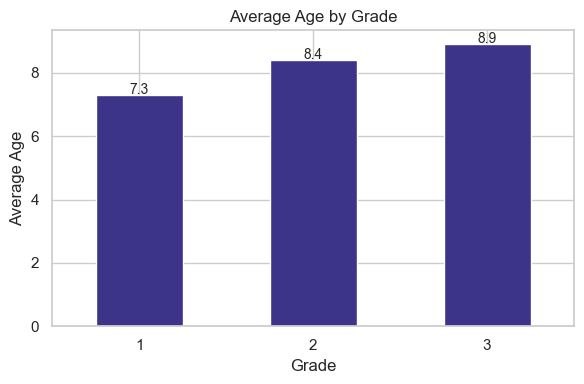

In [2]:
avg_age = df.groupby('Grade')['Age'].mean().round(1)

plt.figure(figsize=(6, 4))
avg_age.plot(kind='bar', color=COLORS[0], edgecolor='white')
plt.title('Average Age by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
for i, v in enumerate(avg_age):
    plt.text(i, v + 0.05, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 1.2 Student Distribution by Grade

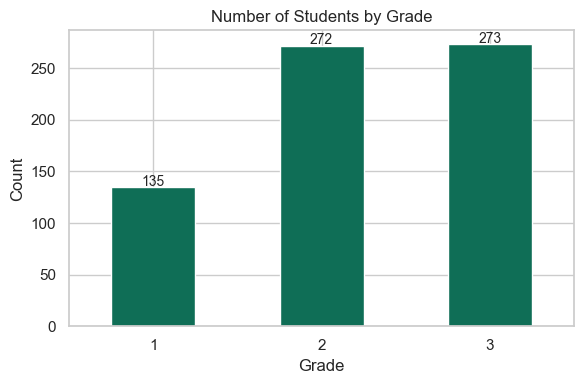

In [3]:
grade_counts = df['Grade'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
grade_counts.plot(kind='bar', color=COLORS[1], edgecolor='white')
plt.title('Number of Students by Grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(grade_counts):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Outcome Variable

### 2.1 Overall At Risk vs Not At Risk

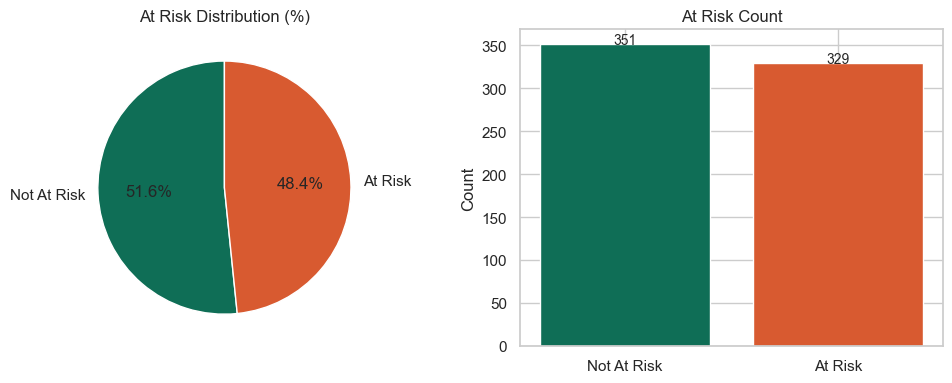

In [4]:
at_risk_counts = df['At Risk'].value_counts()
labels = ['Not At Risk', 'At Risk']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].pie(at_risk_counts, labels=labels, colors=[COLORS[1], COLORS[3]],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('At Risk Distribution (%)')

axes[1].bar(labels, at_risk_counts, color=[COLORS[1], COLORS[3]], edgecolor='white')
axes[1].set_title('At Risk Count')
axes[1].set_ylabel('Count')
for i, v in enumerate(at_risk_counts):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 2.2 At Risk by Grade

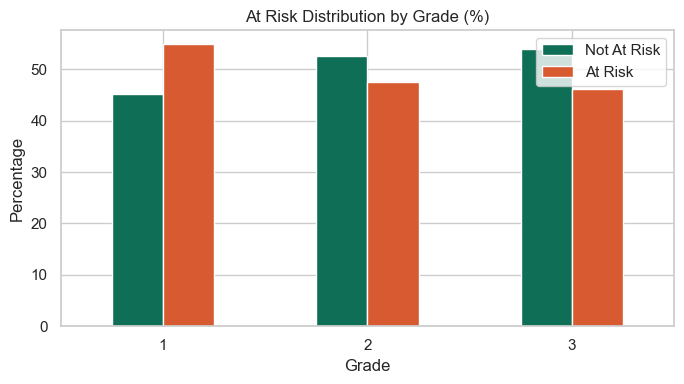

In [5]:
at_risk_grade = df.groupby('Grade')['At Risk'].value_counts(normalize=True).unstack() * 100

at_risk_grade.plot(kind='bar', color=[COLORS[1], COLORS[3]], edgecolor='white', figsize=(7, 4))
plt.title('At Risk Distribution by Grade (%)')
plt.xlabel('Grade')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['Not At Risk', 'At Risk'])
plt.tight_layout()
plt.show()

---
## 3. Response Times

### 3.1 Response Time Distribution — At Risk vs Not At Risk

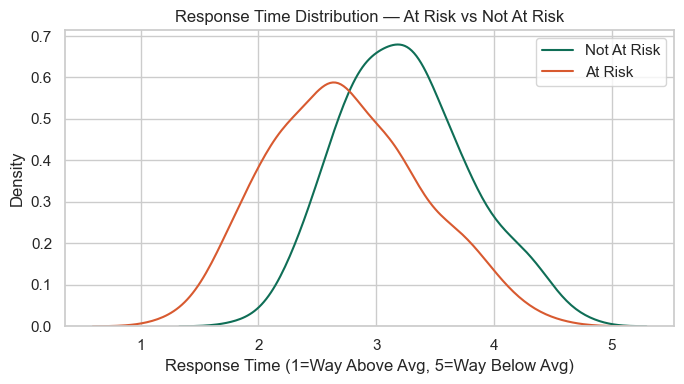

In [6]:
time_cols = [col for col in df.columns if col.startswith('Time_')]
df['Avg Response Time'] = df[time_cols].mean(axis=1)

plt.figure(figsize=(7, 4))
for label, color in zip([0, 1], [COLORS[1], COLORS[3]]):
    sns.kdeplot(df[df['At Risk'] == label]['Avg Response Time'], 
                label='Not At Risk' if label == 0 else 'At Risk', color=color)
plt.title('Response Time Distribution — At Risk vs Not At Risk')
plt.xlabel('Response Time (1=Way Above Avg, 5=Way Below Avg)')
plt.legend()
plt.tight_layout()
plt.show()

df.drop(columns=['Avg Response Time'], inplace=True)

---
## 4. Question Performance

### 4.1 Correct vs Incorrect Answers per Question

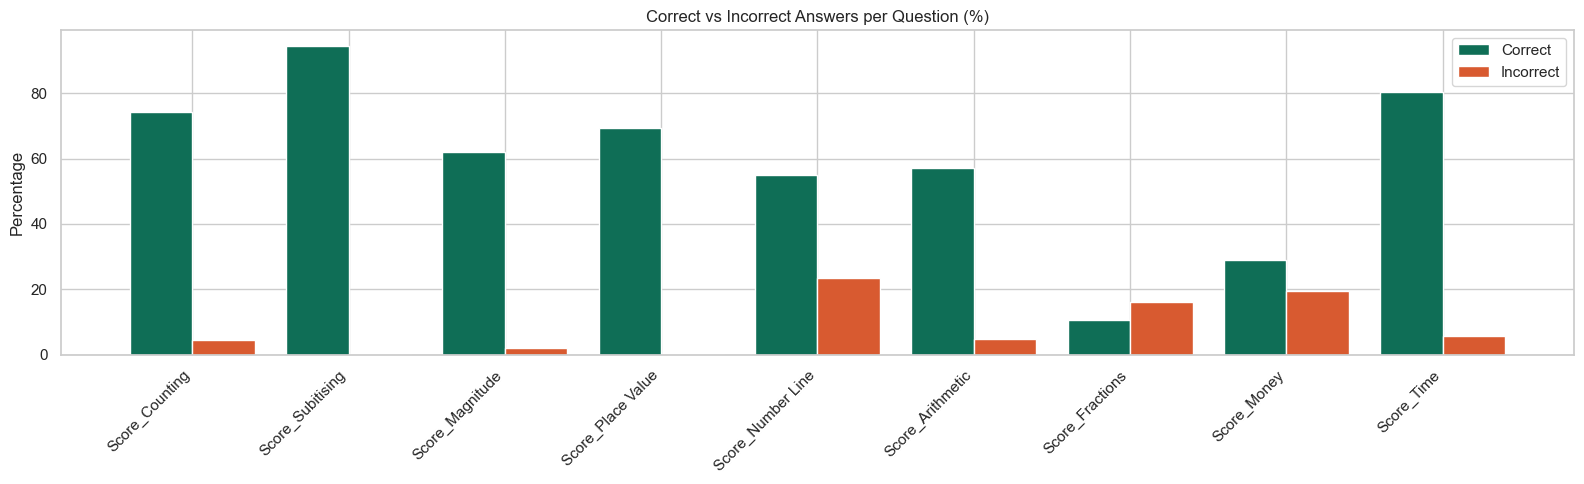

In [7]:
q_score_cols = [col for col in df.columns 
                if col.startswith('Score_') ]

correct_pct = (df[q_score_cols] >= 1).mean() * 100
incorrect_pct = (df[q_score_cols] == 0).mean() * 100

x = np.arange(len(q_score_cols))
width = 0.4

plt.figure(figsize=(16, 5))
plt.bar(x - width/2, correct_pct, width, label='Correct', color=COLORS[1], edgecolor='white')
plt.bar(x + width/2, incorrect_pct, width, label='Incorrect', color=COLORS[3], edgecolor='white')
plt.title('Correct vs Incorrect Answers per Question (%)')
plt.xticks(x, q_score_cols, rotation=45, ha='right')
plt.ylabel('Percentage')
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Average Correct Rate by Category

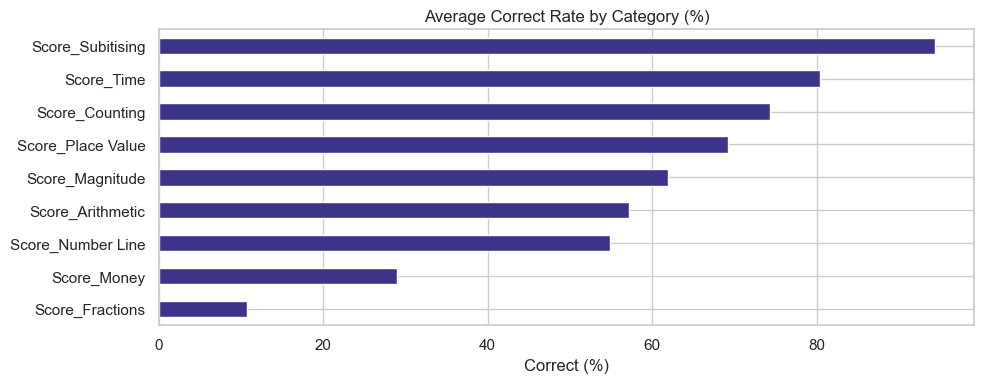

In [8]:
df_cat = df[q_score_cols].copy()
cat_correct = (df_cat >= 1).T.groupby(level=0).mean().T.mean() * 100

plt.figure(figsize=(10, 4))
cat_correct.sort_values().plot(kind='barh', color=COLORS[0], edgecolor='white')
plt.title('Average Correct Rate by Category (%)')
plt.xlabel('Correct (%)')
plt.tight_layout()
plt.show()

### 4.3 Question Performance — At Risk vs Not At Risk

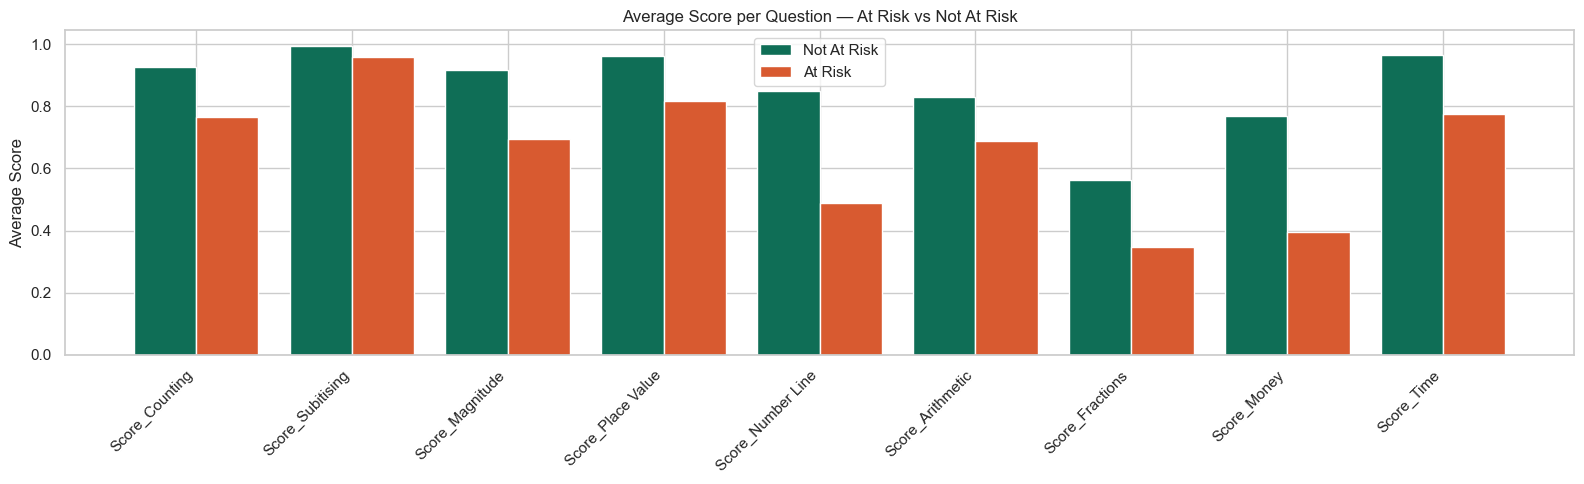

In [9]:
perf_by_risk = df.groupby('At Risk')[q_score_cols].mean()

x = np.arange(len(q_score_cols))
width = 0.4

plt.figure(figsize=(16, 5))
plt.bar(x - width/2, perf_by_risk.loc[0], width, label='Not At Risk', color=COLORS[1], edgecolor='white')
plt.bar(x + width/2, perf_by_risk.loc[1], width, label='At Risk', color=COLORS[3], edgecolor='white')
plt.title('Average Score per Question — At Risk vs Not At Risk')
plt.xticks(x, q_score_cols, rotation=45, ha='right')
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Family & Birth History

### 5.1 Family History Column Distributions

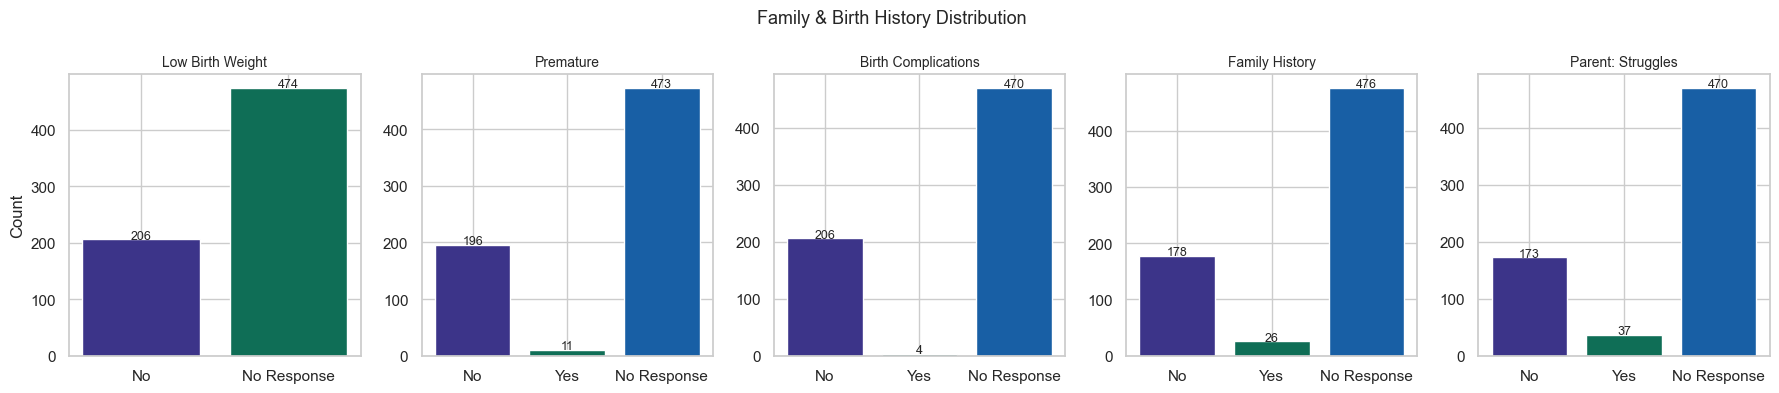

In [10]:
family_cols = [
    'Low_Birth_Weight', 'Born_Prematurely', 'Birth_Complications',
    'Family_Math_Difficulty', 'Parent_Perception_Math'
]
short_labels = ['Low Birth Weight', 'Premature', 'Birth Complications', 'Family History', 'Parent: Struggles']
label_map = {0: 'No', 1: 'Yes', 2: 'No Response'}

fig, axes = plt.subplots(1, len(family_cols), figsize=(18, 4))
for i, col in enumerate(family_cols):
    counts = df[col].value_counts().sort_index()
    counts.index = [label_map.get(x, x) for x in counts.index]
    axes[i].bar(counts.index, counts.values, color=COLORS, edgecolor='white')
    axes[i].set_title(short_labels[i], fontsize=10)
    axes[i].set_ylabel('Count' if i == 0 else '')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=9)

plt.suptitle('Family & Birth History Distribution', fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 Family History vs At Risk

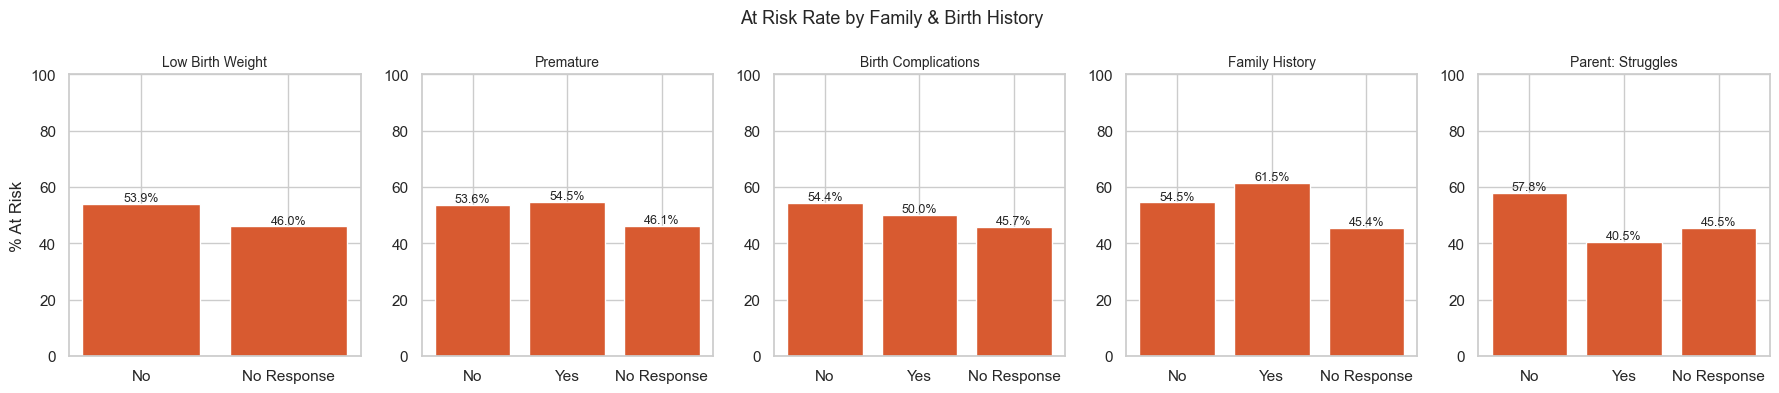

In [11]:
fig, axes = plt.subplots(1, len(family_cols), figsize=(18, 4))

for i, col in enumerate(family_cols):
    cross = df.groupby(col)['At Risk'].mean() * 100
    cross.index = [label_map.get(x, x) for x in cross.index]
    axes[i].bar(cross.index, cross.values, color=COLORS[3], edgecolor='white')
    axes[i].set_title(short_labels[i], fontsize=10)
    axes[i].set_ylabel('% At Risk' if i == 0 else '')
    axes[i].set_ylim(0, 100)
    for j, v in enumerate(cross.values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('At Risk Rate by Family & Birth History', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Academic Performance

### 6.1 Distribution of Performance Gap

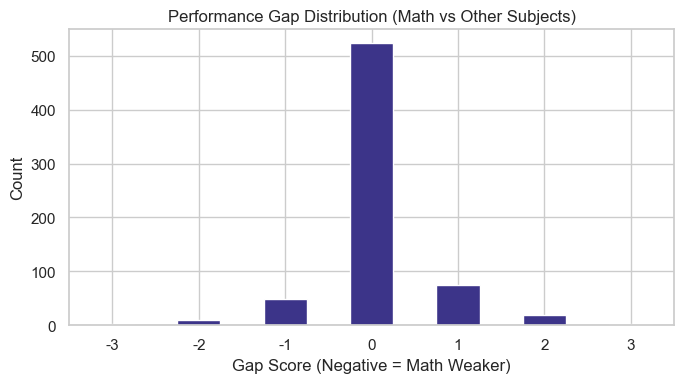

In [12]:
plt.figure(figsize=(7, 4))
df['Performance Gap'].value_counts().sort_index().plot(kind='bar', color=COLORS[0], edgecolor='white')
plt.title('Performance Gap Distribution (Math vs Other Subjects)')
plt.xlabel('Gap Score (Negative = Math Weaker)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.2 Performance Gap vs. At Risk

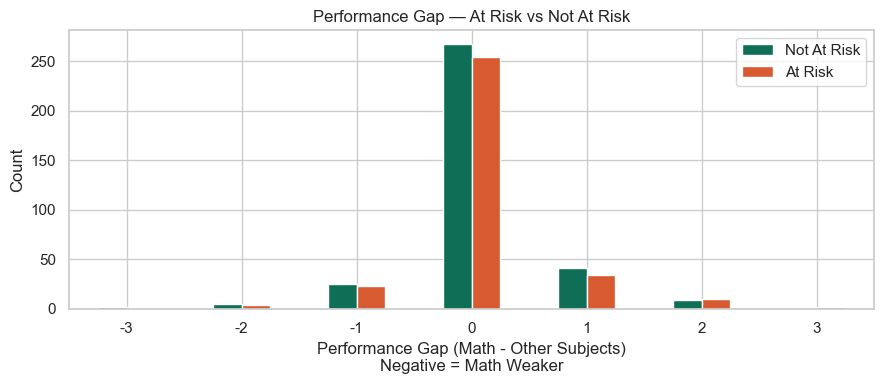

In [13]:
gap_counts = df.groupby(['Performance Gap', 'At Risk']).size().unstack(fill_value=0)
gap_counts.columns = ['Not At Risk', 'At Risk']

gap_counts.plot(kind='bar', figsize=(9, 4), 
                color=[COLORS[1], COLORS[3]], edgecolor='white')
plt.title('Performance Gap — At Risk vs Not At Risk')
plt.xlabel('Performance Gap (Math - Other Subjects)\nNegative = Math Weaker')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

---
## 7. Parent vs Teacher Observations

### 7.1 Child Struggles in Math — Parent vs Teacher View

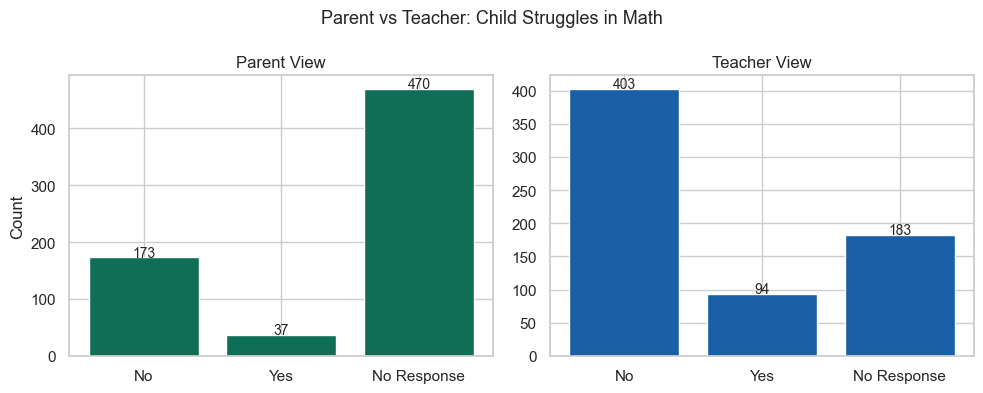

In [14]:
parent_col = 'Parent_Perception_Math'
teacher_col = 'Teacher_Perception_Math'
label_map = {0: 'No', 1: 'Yes', 2: 'No Response'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (col, title) in enumerate([(parent_col, 'Parent View'), (teacher_col, 'Teacher View')]):
    counts = df[col].value_counts().sort_index()
    counts.index = [label_map.get(x, x) for x in counts.index]
    axes[i].bar(counts.index, counts.values, color=COLORS[i+1], edgecolor='white')
    axes[i].set_title(title)
    axes[i].set_ylabel('Count' if i == 0 else '')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('Parent vs Teacher: Child Struggles in Math', fontsize=13)
plt.tight_layout()
plt.show()

### 7.2 Parent vs Teacher Agreement

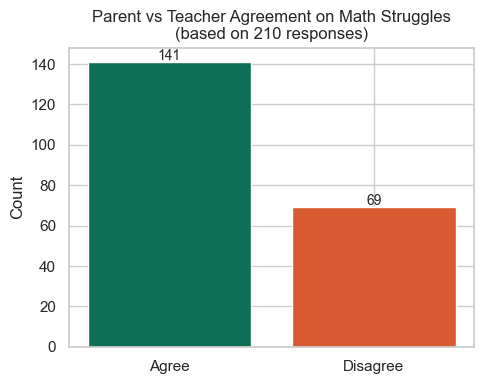

In [15]:
valid_mask = df[parent_col].isin([0, 1]) & df[teacher_col].isin([0, 1])
df_valid = df[valid_mask]

agree = (df_valid[parent_col] == df_valid[teacher_col]).sum()
disagree = (df_valid[parent_col] != df_valid[teacher_col]).sum()

plt.figure(figsize=(5, 4))
plt.bar(['Agree', 'Disagree'], [agree, disagree], color=[COLORS[1], COLORS[3]], edgecolor='white')
plt.title(f'Parent vs Teacher Agreement on Math Struggles\n(based on {len(df_valid)} responses)')
plt.ylabel('Count')
for i, v in enumerate([agree, disagree]):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()



---
## 8. Student Feedback

### 8.1 Enjoyment & Feeling During Assessment

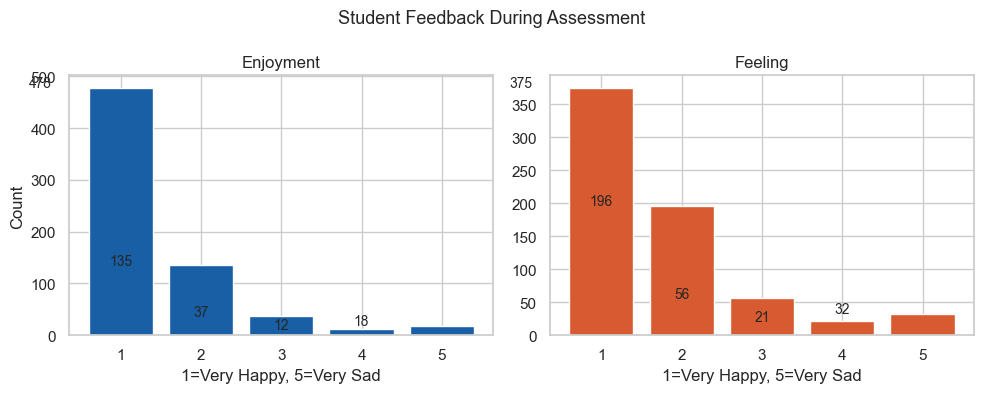

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (col, title) in enumerate([
    ('Enjoyment_Score', 'Enjoyment'),
    ('Student_Feeling', 'Feeling')
]):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color=COLORS[i+2], edgecolor='white')
    axes[i].set_title(title)
    axes[i].set_ylabel('Count' if i == 0 else '')
    axes[i].set_xlabel('1=Very Happy, 5=Very Sad')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('Student Feedback During Assessment', fontsize=13)
plt.tight_layout()
plt.show()

### 8.2 Student Feeling vs At Risk

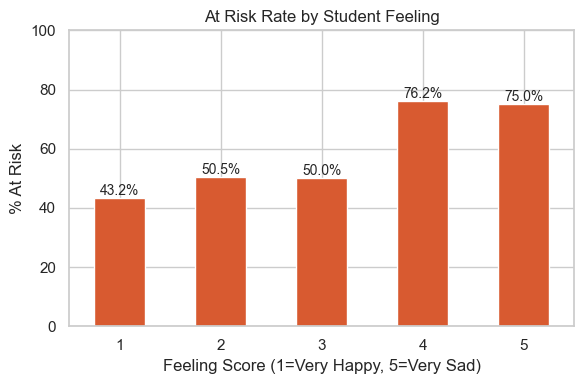

In [17]:
feeling_risk = df.groupby('Student_Feeling')['At Risk'].mean() * 100

plt.figure(figsize=(6, 4))
feeling_risk.plot(kind='bar', color=COLORS[3], edgecolor='white')
plt.title('At Risk Rate by Student Feeling')
plt.xlabel('Feeling Score (1=Very Happy, 5=Very Sad)')
plt.ylabel('% At Risk')
plt.xticks(rotation=0)
plt.ylim(0, 100)
for i, v in enumerate(feeling_risk):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 9. Correlation Analysis

### 9.1 Correlation Heatmap

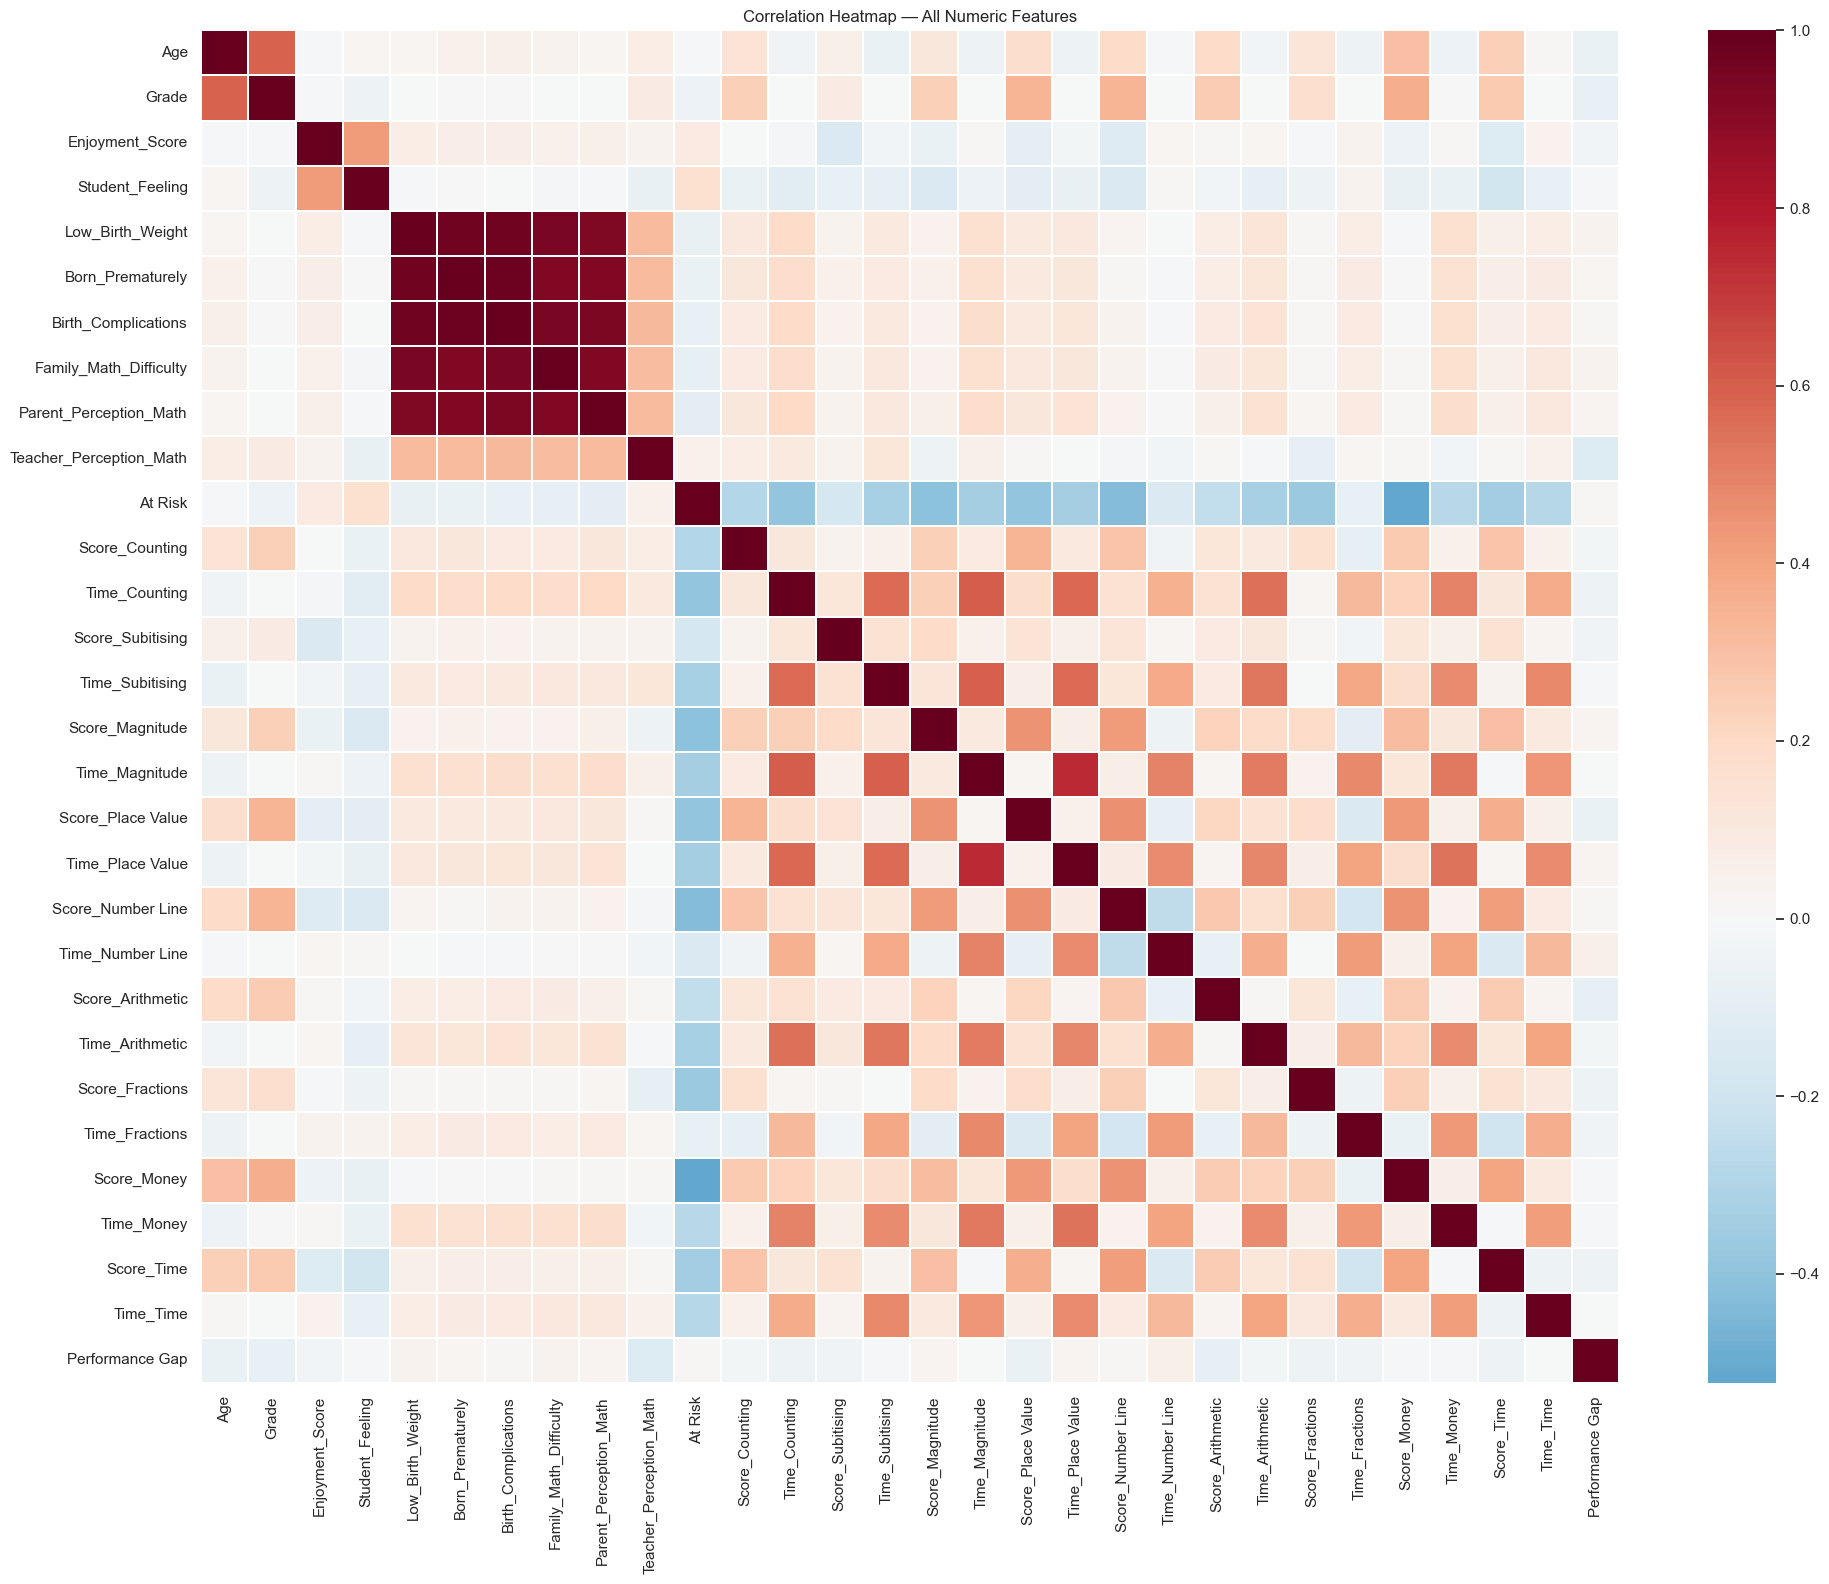

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(20, 16))
sns.heatmap(df[numeric_cols].corr(), 
            cmap='RdBu_r', 
            center=0,
            annot=False,
            linewidths=0.3)
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.show()

### 9.2 Top Features Correlated with At Risk

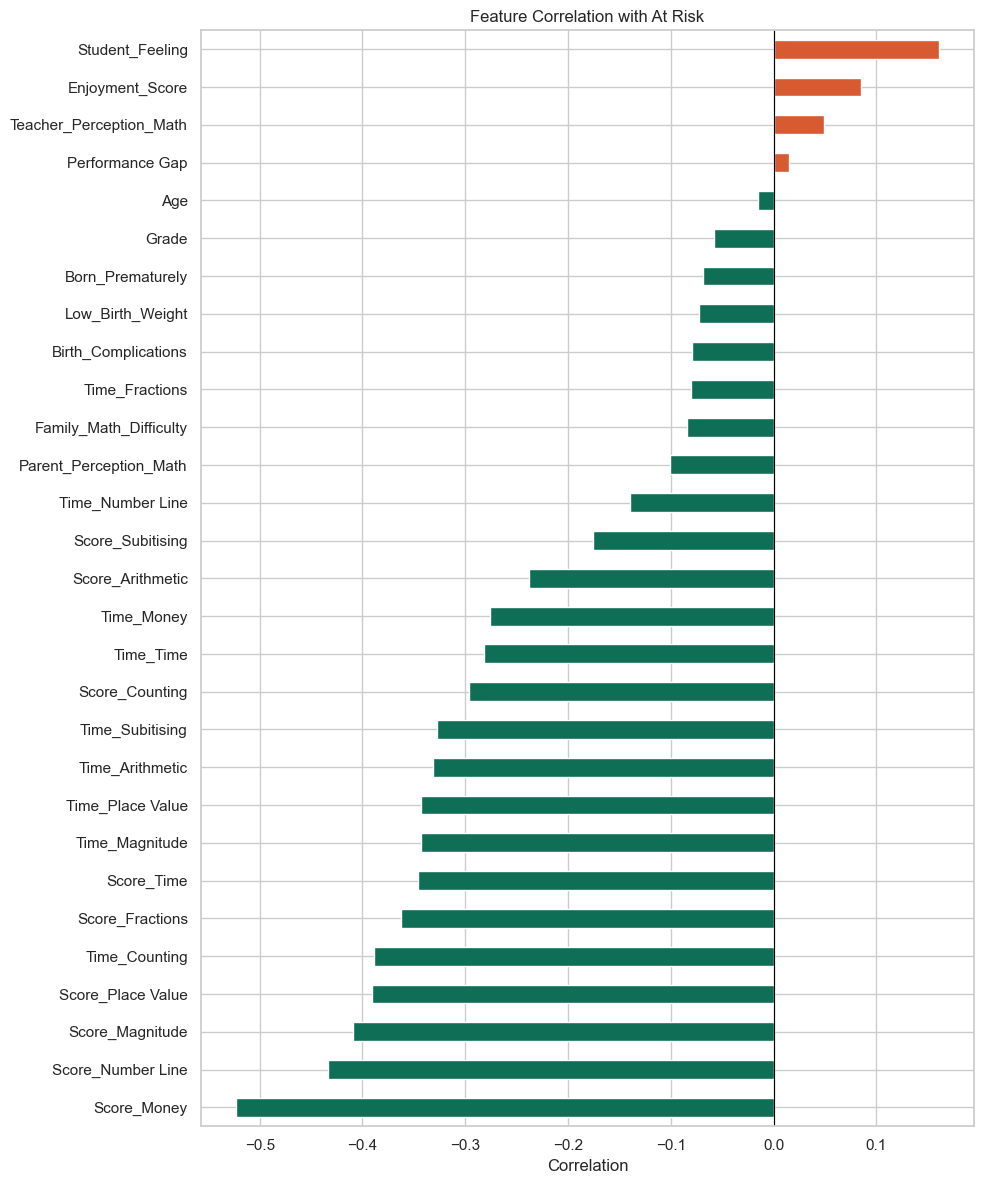

In [19]:
corr_with_target = df[numeric_cols].corr()['At Risk'].drop('At Risk').sort_values()

plt.figure(figsize=(10, 12))
corr_with_target.plot(kind='barh', color=[
    COLORS[3] if v > 0 else COLORS[1] for v in corr_with_target
], edgecolor='white')
plt.title('Feature Correlation with At Risk')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()